In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Robust project root detection (no hardcoding)
# ---------------------------------------------------------
def find_project_root(start_path: Path) -> Path:
    """
    Walk upward from the starting directory until we find a folder
    that contains both 'data' and 'scripts'. That is the project root.
    """
    for parent in [start_path] + list(start_path.parents):
        if (parent / "data").exists() and (parent / "scripts").exists():
            return parent
    raise RuntimeError("Project root not found. Expected folders: data/, scripts/")

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_LABELS_DIR = PROJECT_ROOT / "data" / "labels"
MODEL_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Labels dir:", DATA_LABELS_DIR)
print("Models dir:", MODEL_DIR)


Project root: c:\Trading\Projects\ES_AI_Project
Labels dir: c:\Trading\Projects\ES_AI_Project\data\labels
Models dir: c:\Trading\Projects\ES_AI_Project\models


In [6]:
labeled_path = DATA_LABELS_DIR / "labeled.csv"

if not labeled_path.exists():
    raise FileNotFoundError(f"labeled.csv not found at {labeled_path}")

df = pd.read_csv(labeled_path)
df.head()


,Time,Close,Open,High,Low,Body,UpperWick,LowerWick,Range,C1,...,DistLocalLow10,SweepUp,SweepDown,IsTradeBar,IsLong,IsShort,BarsSinceEntry,FutureClose,FutureRet,ShortSuccess
0,2026-02-16 09:21:00,6906.75,6906.25,6907.25,6905.50,0.50,0.50,0.75,1.75,6906.25,...,7,0,0,0,0,0,0,6900.25,-26.0,1
1,2026-02-16 09:22:00,6904.50,6906.50,6906.75,6901.75,-2.00,0.25,2.75,5.00,6906.75,...,11,0,0,0,0,0,0,6897.75,-27.0,1
2,2026-02-16 09:23:00,6903.00,6904.50,6904.50,6900.75,-1.50,0.00,2.25,3.75,6904.50,...,9,0,0,0,0,0,0,6898.00,-20.0,1
3,2026-02-16 09:24:00,6904.25,6903.00,6904.50,6903.00,1.25,0.25,0.00,1.50,6903.00,...,14,0,0,0,0,0,0,6894.50,-39.0,1
4,2026-02-16 09:25:00,6903.00,6904.25,6904.50,6902.50,-1.25,0.25,0.50,2.00,6904.25,...,9,0,0,0,0,0,0,6896.25,-27.0,1


In [7]:
TARGET = "ShortSuccess"

# Exclude non-feature columns
EXCLUDE_COLS = ["Time", "FutureClose", "FutureRet", "ShortSuccess"]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

len(FEATURE_COLS), FEATURE_COLS[:10]


(55,
 ['Close',
  'Open',
  'High',
  'Low',
  'Body',
  'UpperWick',
  'LowerWick',
  'Range',
  'C1',
  'H1'])

In [8]:
X = df[FEATURE_COLS].astype(float)
y = df[TARGET].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train.shape, X_val.shape


((17790, 55), (4448, 55))

In [9]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [10]:
y_pred = (model.predict_proba(X_val)[:,1] > 0.5).astype(int)

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Accuracy: 0.4449190647482014
Precision: 0.3955941669252249
Recall: 0.7099109131403119
F1 Score: 0.5080693365212193

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.27      0.36      2652
           1       0.40      0.71      0.51      1796

    accuracy                           0.44      4448
   macro avg       0.49      0.49      0.44      4448
weighted avg       0.50      0.44      0.42      4448



<Figure size 1200x800 with 0 Axes>

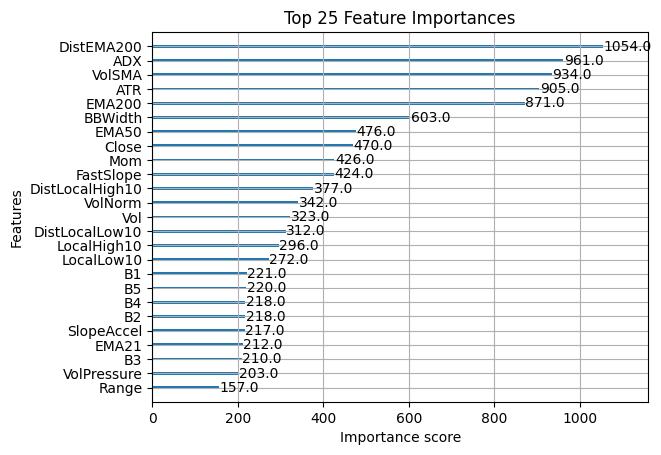

In [11]:
plt.figure(figsize=(12,8))
xgb.plot_importance(model, max_num_features=25)
plt.title("Top 25 Feature Importances")
plt.show()


In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "xgb_model.json"
model.save_model(model_path)

feature_path = MODEL_DIR / "feature_list.txt"
with open(feature_path, "w") as f:
    for col in FEATURE_COLS:
        f.write(col + "\n")

model_path, feature_path


(WindowsPath('c:/Trading/Projects/ES_AI_Project/models/xgb_model.json'),
 WindowsPath('c:/Trading/Projects/ES_AI_Project/models/feature_list.txt'))

In [13]:
test_model = xgb.XGBClassifier()
test_model.load_model(model_path)

print("Model reloaded successfully.")


Model reloaded successfully.
